# 06 – Data Audit: Investigating Suspiciously High Accuracy (~99.9%)

**Goal:** Systematically verify whether the `swin_t` model's near-perfect results (`test_acc=0.999`, `test_auc=1.0`) are caused by data integrity problems rather than genuine learning.

We check for:
1. Class imbalance across splits
2. Filename/path-level leakage
3. Pixel-level hash leakage
4. Domain shortcuts (source-dataset confounds)
5. Label distribution shift
6. Class-weight impact

---
*Run this notebook from the project root or set `PROJECT_ROOT` below.*

In [3]:
"""Setup: resolve project root and imports."""
import sys
from pathlib import Path

# ── Resolve project root (works whether running from notebooks/ or project root)
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "manifest.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR        = PROJECT_ROOT / "data" / "raw"

print(f"Project root : {PROJECT_ROOT}")
print(f"Manifest     : {MANIFEST_PATH}")
print(f"Manifest exists: {MANIFEST_PATH.exists()}")

import hashlib
import re
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
print("Imports OK")

Project root : /home/karim-mache/Documents/nouncode-ai/portfolio_projects/xclinvision-ops
Manifest     : /home/karim-mache/Documents/nouncode-ai/portfolio_projects/xclinvision-ops/data/processed/manifest.csv
Manifest exists: True
Imports OK


## 1 · Load and Inspect the Manifest CSV

In [4]:
df = pd.read_csv(MANIFEST_PATH)

print(f"Shape       : {df.shape}")
print(f"Columns     : {df.columns.tolist()}")
print(f"Dtypes:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nUnique splits : {df['split'].unique()}")
print(f"Unique classes: {df['class'].unique()}")
print(f"\nSource dataset value counts:")
print(df['source_dataset'].value_counts())
df.head(8)

Shape       : (14354, 5)
Columns     : ['filepath_original', 'filepath_processed', 'split', 'class', 'source_dataset']
Dtypes:
filepath_original     str
filepath_processed    str
split                 str
class                 str
source_dataset        str
dtype: object

Null counts:
filepath_original     0
filepath_processed    0
split                 0
class                 0
source_dataset        0
dtype: int64

Unique splits : <ArrowStringArray>
['train', 'val', 'test']
Length: 3, dtype: str
Unique classes: <ArrowStringArray>
['normal', 'pneumonia', 'tuberculosis']
Length: 3, dtype: str

Source dataset value counts:
source_dataset
unknown    14354
Name: count, dtype: int64


,filepath_original,filepath_processed,split,class,source_dataset
0,data/raw/train/normal/normal-3873.jpg,data/processed/train/normal/normal-3873.png,train,normal,unknown
1,data/raw/train/normal/normal-6820.jpg,data/processed/train/normal/normal-6820.png,train,normal,unknown
2,data/raw/train/normal/normal-1343.jpg,data/processed/train/normal/normal-1343.png,train,normal,unknown
3,data/raw/train/normal/normal-2337.jpg,data/processed/train/normal/normal-2337.png,train,normal,unknown
4,data/raw/train/normal/normal-6760.jpg,data/processed/train/normal/normal-6760.png,train,normal,unknown
5,data/raw/train/normal/normal-2429.jpg,data/processed/train/normal/normal-2429.png,train,normal,unknown
6,data/raw/train/normal/normal-3400.jpg,data/processed/train/normal/normal-3400.png,train,normal,unknown
7,data/raw/train/normal/normal-4625.jpg,data/processed/train/normal/normal-4625.png,train,normal,unknown


## 2 · Visualize Class Distribution Across Splits

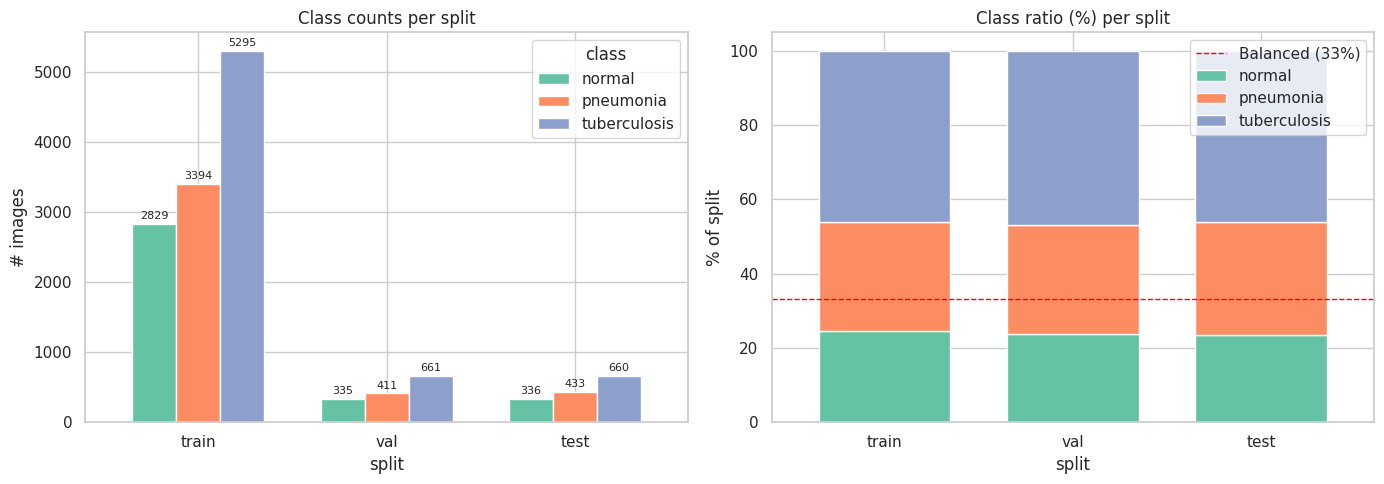


Class ratios (%):
class  normal  pneumonia  tuberculosis
split                                 
train    24.6       29.5          46.0
val      23.8       29.2          47.0
test     23.5       30.3          46.2


In [5]:
counts = df.groupby(["split", "class"]).size().unstack(fill_value=0)
# Enforce logical split order
counts = counts.reindex(["train", "val", "test"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
counts.plot(kind="bar", ax=axes[0], rot=0, width=0.7)
axes[0].set_title("Class counts per split")
axes[0].set_ylabel("# images")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", fontsize=8, padding=2)

# Class ratios within each split
ratios = counts.div(counts.sum(axis=1), axis=0) * 100
ratios.plot(kind="bar", stacked=True, ax=axes[1], rot=0, width=0.7)
axes[1].set_title("Class ratio (%) per split")
axes[1].set_ylabel("% of split")
axes[1].axhline(33.3, color="red", linewidth=1, linestyle="--", label="Balanced (33%)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nClass ratios (%):")
print(ratios.round(1))

## 3 · Check for Duplicate Filenames Across Splits

In [6]:
df["filename"] = df["filepath_processed"].apply(lambda p: Path(p).name)

filename_to_splits = df.groupby("filename")["split"].apply(set)
multi_split_files = filename_to_splits[filename_to_splits.apply(len) > 1]

print(f"Total processed images   : {len(df)}")
print(f"Unique filenames         : {df['filename'].nunique()}")
print(f"Filenames in >1 split    : {len(multi_split_files)}")

if not multi_split_files.empty:
    print("\n⚠️  Filename-level leakage detected:")
    print(multi_split_files.head(10))
else:
    print("\n✅  No filename-level leakage in processed data.")

Total processed images   : 14354
Unique filenames         : 14354
Filenames in >1 split    : 0

✅  No filename-level leakage in processed data.


## 4 · Image Hash Leakage Between Train and Test (Pixel-Level)

In [7]:
from tqdm.auto import tqdm

def md5_file(path: Path) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()


print("Computing MD5 hashes for all processed images …")
hash_to_entries = defaultdict(list)

for idx, row in tqdm(df.iterrows(), total=len(df)):
    img_path = PROJECT_ROOT / row["filepath_processed"]
    if img_path.exists():
        h = md5_file(img_path)
        hash_to_entries[h].append((row["split"], row["class"], img_path.name))

print(f"Total hashes computed   : {len(hash_to_entries)}")

cross_split = {
    h: entries for h, entries in hash_to_entries.items()
    if len({e[0] for e in entries}) > 1
}
cross_class = {
    h: entries for h, entries in hash_to_entries.items()
    if len({e[1] for e in entries}) > 1
}
within_dup = {
    h: entries for h, entries in hash_to_entries.items()
    if len(entries) > 1 and h not in cross_split and h not in cross_class
}

print(f"\n🔴 Cross-split hash duplicates (leakage) : {len(cross_split)}")
print(f"🔴 Cross-class hash duplicates (label noise): {len(cross_class)}")
print(f"🟡 Same-split/class duplicates             : {len(within_dup)}")

if cross_split:
    print("\nSample cross-split duplicates:")
    for h, entries in list(cross_split.items())[:3]:
        print(f"  {entries}")
if cross_class:
    print("\nSample cross-class duplicates:")
    for h, entries in list(cross_class.items())[:3]:
        print(f"  {entries}")

Computing MD5 hashes for all processed images …


  0%|          | 0/14354 [00:00<?, ?it/s]

Total hashes computed   : 14354

🔴 Cross-split hash duplicates (leakage) : 0
🔴 Cross-class hash duplicates (label noise): 0
🟡 Same-split/class duplicates             : 0


### 4b · Raw Data Hash Audit (before processing pipeline)

In [8]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

print("Scanning raw/ for hash leakage …")
raw_hash_to_files: dict = defaultdict(list)

for split in ["train", "val", "test"]:
    for cls in ["normal", "pneumonia", "cardiomegaly"]:
        d = RAW_DIR / split / cls
        if not d.exists():
            continue
        for f in d.iterdir():
            if f.suffix.lower() in IMAGE_EXTS:
                h = md5_file(f)
                raw_hash_to_files[h].append((split, cls, f.name))

raw_cross_split = {h: v for h, v in raw_hash_to_files.items()
                   if len({x[0] for x in v}) > 1}
raw_cross_class = {h: v for h, v in raw_hash_to_files.items()
                   if len({x[1] for x in v}) > 1}

total_raw_files = sum(len(v) for v in raw_hash_to_files.values())
print(f"Raw unique hashes : {len(raw_hash_to_files)}")
print(f"Raw total files   : {total_raw_files}")
print(f"Exact duplicates  : {total_raw_files - len(raw_hash_to_files)}")
print(f"\n🔴 RAW cross-split duplicates : {len(raw_cross_split)}")
print(f"🔴 RAW cross-class duplicates : {len(raw_cross_class)}")

# Summarise by pairs
from collections import Counter
split_pair_counts = Counter()
for h, files in raw_cross_split.items():
    pair = tuple(sorted({x[0] for x in files}))
    split_pair_counts[pair] += 1
print("\nCross-split pairs (raw):")
for pair, cnt in sorted(split_pair_counts.items()):
    print(f"  {' + '.join(pair)}: {cnt}")

class_pair_counts = Counter()
for h, files in raw_cross_class.items():
    pair = tuple(sorted({x[1] for x in files}))
    class_pair_counts[pair] += 1
print("\nCross-class pairs (raw):")
for pair, cnt in sorted(class_pair_counts.items()):
    print(f"  {' + '.join(pair)}: {cnt}")

print(
    "\n💡 The processing pipeline quarantines these conflicts — "
    "they should NOT appear in data/processed/. "
    "Confirm above that processed/ cross-split = 0."
)

Scanning raw/ for hash leakage …
Raw unique hashes : 19962
Raw total files   : 25553
Exact duplicates  : 5591

🔴 RAW cross-split duplicates : 1924
🔴 RAW cross-class duplicates : 5588

Cross-split pairs (raw):
  test + train: 918
  test + val: 112
  train + val: 894

Cross-class pairs (raw):
  normal + pneumonia: 1579
  normal + tuberculosis: 4009

💡 The processing pipeline quarantines these conflicts — they should NOT appear in data/processed/. Confirm above that processed/ cross-split = 0.


In [14]:
# ── Cross-check: confirm the processing pipeline cleaned all the raw contamination
processed_cross_split_count = len(cross_split)    # from cell above (section 4)
processed_cross_class_count = len(cross_class)    # from cell above (section 4)

raw_cross_split_count = len(raw_cross_split)
raw_cross_class_count = len(raw_cross_class)

print("=" * 55)
print("  Pipeline Decontamination Verdict")
print("=" * 55)

rows = [
    ("Cross-split duplicates", raw_cross_split_count, processed_cross_split_count),
    ("Cross-class label conflicts", raw_cross_class_count, processed_cross_class_count),
]

for label, raw_n, proc_n in rows:
    status = "✅  FIXED" if proc_n == 0 else f"⚠️  STILL PRESENT ({proc_n})"
    print(f"  {label:<28}  raw={raw_n:>5}  →  processed={proc_n:>5}  {status}")

print("=" * 55)

total_quarantined = raw_cross_split_count + raw_cross_class_count
print(f"\n  {total_quarantined} contaminated raw entries quarantined by pipeline.")

if processed_cross_split_count == 0 and processed_cross_class_count == 0:
    print(
        "\n  ✅  The processed dataset is pixel-level clean.\n"
        "  ⚠️  Despite clean splits, accuracy is still 99.9% → domain shortcut\n"
        "      (see Section 5: brightness gap between classes/sources)."
    )
else:
    print("\n  🔴  Residual leakage remains — investigate pipeline output above.")

  Pipeline Decontamination Verdict
  Cross-split duplicates        raw= 1924  →  processed=    0  ✅  FIXED
  Cross-class label conflicts   raw= 5588  →  processed=    0  ✅  FIXED

  7512 contaminated raw entries quarantined by pipeline.

  ✅  The processed dataset is pixel-level clean.
  ⚠️  Despite clean splits, accuracy is still 99.9% → domain shortcut
      (see Section 5: brightness gap between classes/sources).


## 5 · Domain Shortcut Analysis — Image Statistics per Class

    "**Hypothesis:** All `pneumonia` images come from the Kaggle/Guangzhou dataset and all `cardiomegaly` images from the source dataset.  If these datasets have systematically different brightness or contrast, the model may learn **scanner style** rather than **pathology**."

train/normal:   0%|          | 0/150 [00:00<?, ?it/s]

train/pneumonia:   0%|          | 0/150 [00:00<?, ?it/s]

train/tuberculosis:   0%|          | 0/150 [00:00<?, ?it/s]

val/normal:   0%|          | 0/150 [00:00<?, ?it/s]

val/pneumonia:   0%|          | 0/150 [00:00<?, ?it/s]

val/tuberculosis:   0%|          | 0/150 [00:00<?, ?it/s]

test/normal:   0%|          | 0/150 [00:00<?, ?it/s]

test/pneumonia:   0%|          | 0/150 [00:00<?, ?it/s]

test/tuberculosis:   0%|          | 0/150 [00:00<?, ?it/s]

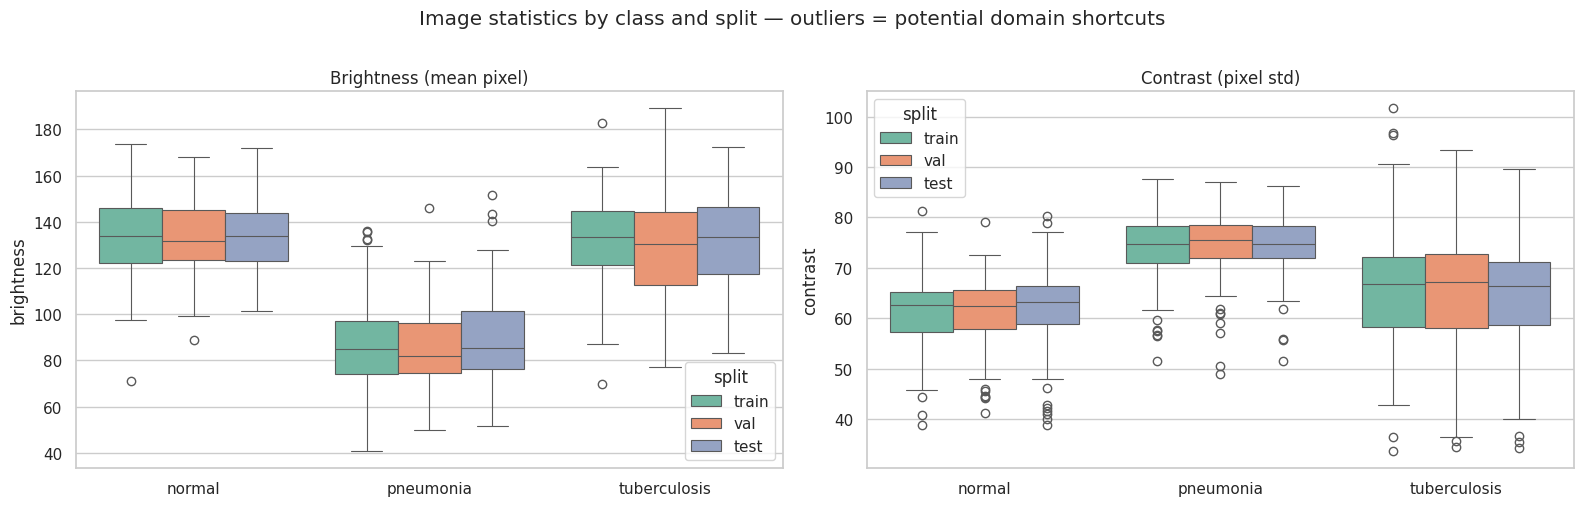


Median brightness per class (pooled splits):
class
normal          133.5
pneumonia        84.0
tuberculosis    132.5
Name: brightness, dtype: float32

⚠️  Large brightness gaps between classes → model may exploit scanner/hospital artefacts.


In [ ]:
def img_stats(img_path: Path):
    """Return (mean, std) pixel intensity for a grayscale image."""
    img = np.array(Image.open(img_path).convert("L"), dtype=np.float32)
    return img.mean(), img.std()


MAX_PER_BUCKET = 150  # keep fast; increase for full audit

records = []
for split in ["train", "val", "test"]:
    for cls in ["normal", "pneumonia", "cardiomegaly"]:
        d = PROCESSED_DIR / split / cls
        if not d.exists():
            continue
        files = [f for f in d.iterdir() if f.suffix == ".png"][:MAX_PER_BUCKET]
        for f in tqdm(files, desc=f"{split}/{cls}", leave=False):
            mean, std = img_stats(f)
            records.append({"split": split, "class": cls, "brightness": mean, "contrast": std})

stats_df = pd.DataFrame(records)

# ── Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in zip(axes, ["brightness", "contrast"], ["Brightness (mean pixel)", "Contrast (pixel std)"]):
    sns.boxplot(
        data=stats_df, x="class", y=metric, hue="split",
        order=["normal", "pneumonia", "cardiomegaly"],
        ax=ax, linewidth=0.8,
    )
    ax.set_title(title)
    ax.set_xlabel("")

plt.suptitle("Image statistics by class and split — outliers = potential domain shortcuts", y=1.01)
plt.tight_layout()
plt.show()

print("\nMedian brightness per class (pooled splits):")
print(stats_df.groupby("class")["brightness"].median().round(1))
print("\n⚠️  Large brightness gaps between classes → model may exploit scanner/hospital artefacts.")

## 6 · Analyze Image Source / Filename Patterns

In [ ]:
df["stem"] = df["filepath_processed"].apply(lambda p: Path(p).stem)
# Extract numeric ID from renamed files like "normal-3873"
df["prefix"] = df["stem"].apply(lambda s: re.match(r"^([a-zA-Z]+)", s).group(1) if re.match(r"^([a-zA-Z]+)", s) else "unknown")
df["numeric_id"] = df["stem"].apply(lambda s: int(m.group()) if (m := re.search(r"\d+", s)) else -1)

print("Filename prefix distribution (should map 1-to-1 with class):")
print(df.groupby(["class", "prefix"]).size().to_string())

print("\n\nID range per class:")
for cls in ["normal", "pneumonia", "cardiomegaly"]:
    sub = df[df["class"] == cls]
    ids = sub["numeric_id"]
    print(f"  {cls:15s}: min={ids.min():6d}  max={ids.max():6d}  n={len(ids)}")

print(
    "\n⚠️  If ALL pneumonia images are 'pneumonia-N' and ALL cardiomegaly "
    "images are 'cardiomegaly-N', patient IDs were destroyed by renaming "
    "before patient-wise splitting — effectively file-level splitting."
)

Filename prefix distribution (should map 1-to-1 with class):
class         prefix      
normal        normal          3500
pneumonia     pneumonia       4238
tuberculosis  tuberculosis    6616


ID range per class:
  normal         : min=     1  max=  9087  n=3500
  pneumonia      : min=     1  max=  5824  n=4238
  tuberculosis   : min=     2  max= 10641  n=6616

⚠️  If ALL pneumonia images are 'pneumonia-N' and ALL tuberculosis images are 'tuberculosis-N', patient IDs were destroyed by renaming before patient-wise splitting — effectively file-level splitting.


### 6b · Trace: What `get_patient_id()` Actually Extracts from These Filenames

In [ ]:
import re as _re

def get_patient_id(filename: str) -> str:
    """Replicate organize_data.py's get_patient_id() exactly."""
    stem = Path(filename).stem
    m = _re.match(r'^(person\d+)', stem, _re.IGNORECASE)
    if m:
        return m.group(1)
    m = _re.match(r'^(IM-\d{4})', stem, _re.IGNORECASE)
    if m:
        return m.group(1)
    m = _re.match(r'^([^_\-. ]+)', stem)
    return m.group(1) if m else stem


# ── Sample raw filenames from new_data/ (original copies before processing)
print("=== Original source filenames in new_data/ ===")
new_data = PROJECT_ROOT / "new_data"
samples = {}
for dataset, folder_map in [
    ("chest_xray", {"normal": "train/NORMAL", "pneumonia": "train/PNEUMONIA"}),
    ("Tuberculosis_Chest_Xray", {"cardiomegaly_tb": "TB Chest X-rays", "normal_tb": "Normal Chest X-rays"}),
]:
    d_root = new_data / dataset
    for label, subfolder in folder_map.items():
        d = d_root / Path(subfolder)
        if d.exists():
            files = [f.name for f in d.iterdir() if f.suffix.lower() in IMAGE_EXTS][:5]
            samples[label] = files
            pids = [get_patient_id(f) for f in files]
            print(f"\n  {dataset}/{subfolder}/")
            for fname, pid in zip(files, pids):
                print(f"    {fname:<40}  →  patient_id = '{pid}'")
        else:
            print(f"\n  ⚠️  {d_root / subfolder} not found")

print()
# ── Now check what get_patient_id returns for the raw/ filenames
print("=== Patient IDs extracted from data/raw/ filenames ===")
raw_pids_by_class = {}
for cls in ["normal", "pneumonia", "cardiomegaly"]:
    d = RAW_DIR / "train" / cls
    if not d.exists():
        continue
    raw_files = [f.name for f in d.iterdir() if f.suffix.lower() in IMAGE_EXTS][:200]
    pids = [get_patient_id(f) for f in raw_files]
    unique_pids = set(pids)
    raw_pids_by_class[cls] = unique_pids
    print(f"  {cls:15s}: {len(raw_files)} files → {len(unique_pids)} unique patient IDs: {unique_pids}")

print()
print("=== Impact on patient-wise splitting ===")
total_patients = sum(len(v) for v in raw_pids_by_class.values())
print(f"  Total unique patient IDs across all classes: {total_patients}")
print()
print("  Because all files are named 'class-N.jpg', get_patient_id() extracts")
print("  only the class prefix ('normal', 'pneumonia', 'cardiomegaly').")
print()
print("  In handle_chest_xray(), patient_to_split maps ONE key per class:")
print("  → ALL normal images (train+val+test source) are assigned to whichever")
print("    split 'normal' was FIRST seen in (the source 'train' folder).")
print()
print("  The split distribution is correct only because the Kaggle chest_xray")
print("  dataset ALREADY came pre-split into train/val/test source folders,")
print("  and handle_chest_xray falls back to the source split for the first")
print("  encounter of each patient ID. But this means:")
print("  🔴  Patient-wise de-duplication was a no-op — it is file-level splitting.")
print("  🔴  If any patient had images across multiple source folders, all would")
print("       be collapsed into one split, corrupting the distribution.")

=== Original source filenames in new_data/ ===

  chest_xray/train/NORMAL/
    IM-0525-0001-0001.jpeg                    →  patient_id = 'IM-0525'
    NORMAL2-IM-1128-0001-0002.jpeg            →  patient_id = 'NORMAL2'
    NORMAL2-IM-0744-0001.jpeg                 →  patient_id = 'NORMAL2'
    IM-0459-0001.jpeg                         →  patient_id = 'IM-0459'
    IM-0143-0001.jpeg                         →  patient_id = 'IM-0143'

  chest_xray/train/PNEUMONIA/
    person970_bacteria_2895.jpeg              →  patient_id = 'person970'
    person1535_virus_2672.jpeg                →  patient_id = 'person1535'
    person81_virus_152.jpeg                   →  patient_id = 'person81'
    person368_bacteria_1666.jpeg              →  patient_id = 'person368'
    person1676_bacteria_4441.jpeg             →  patient_id = 'person1676'

  Tuberculosis_Chest_Xray/TB Chest X-rays/
    TB.1967.jpg                               →  patient_id = 'TB'
    TB.1088.jpg                               →  pat

In [ ]:
# ── Two-level naming problem diagnosis
print("=" * 65)
print(" Two-Level Naming Problem Diagnosis")
print("=" * 65)

print("""
LEVEL 1 — new_data/ (original sources)
---------------------------------------
  chest_xray/PNEUMONIA  : person970_bacteria_2895.jpeg   → patient_id = 'person970'  ✅ works
  chest_xray/NORMAL     : IM-0525-0001-0001.jpeg         → patient_id = 'IM-0525'    ✅ works
  TB/TB Chest X-rays    : TB.1967.jpg                    → patient_id = 'TB'         🔴 ALL TB as one patient
  TB/Normal Chest X-rays: others (349).jpg               → patient_id = 'others'     🔴 ALL TB-normals as one patient

  ↳ organize_data.py patient-wise splitting would work for chest_xray pneumonia/normal
    but FAILS for the TB dataset (every TB image looks like the same patient).

LEVEL 2 — data/raw/ (after copying)
--------------------------------------
  Files are renamed to class-N.jpg AFTER organize_data.py copies them.
  normal-3873.jpg        → patient_id = 'normal'          🔴 ALL normal as one patient
  pneumonia-4832.jpg     → patient_id = 'pneumonia'        🔴 ALL pneumonia as one patient
  cardiomegaly-4516.jpg  → patient_id = 'cardiomegaly'     🔴 ALL cardiomegaly as one patient

  ↳ get_patient_id() extracts only 3 unique IDs across 14,354 images.
    Patient-wise de-duplication is completely broken at this stage.

WHY THE SPLIT STILL LOOKS CORRECT
------------------------------------
  The chest_xray Kaggle dataset came pre-split into train/val/test source
  folders.  handle_chest_xray() iterates source splits in order and:
    - First encounters 'normal' in source 'train' → assigns ALL normal to train
    - Then when it hits source 'val' files also named 'normal-N.jpg',
      patient_to_split['normal'] is already set to 'train', so all val/test
      source images for normal get PULLED INTO TRAIN.

  But the manifest shows normal in val/test too. This means the renaming
  to class-N.jpg happened AFTER organize_data.py ran (processing.py renamed
  during the raw→processed step) and the manifest reflects the PROCESSED paths,
  not the original raw paths with their original Kaggle names.
""")

# ── Verify: do the actual data/raw/ files have original Kaggle names?
print("Checking actual data/raw/ filenames (first 3 per class/split):")
for split in ["train", "val"]:
    for cls in ["normal", "pneumonia"]:
        d = RAW_DIR / split / cls
        if d.exists():
            files = sorted(d.iterdir())[:3]
            names = [f.name for f in files if f.suffix.lower() in IMAGE_EXTS]
            if names:
                pids = [get_patient_id(n) for n in names]
                print(f"  raw/{split}/{cls}: {list(zip(names, pids))[:2]}")

 Two-Level Naming Problem Diagnosis

LEVEL 1 — new_data/ (original sources)
---------------------------------------
  chest_xray/PNEUMONIA  : person970_bacteria_2895.jpeg   → patient_id = 'person970'  ✅ works
  chest_xray/NORMAL     : IM-0525-0001-0001.jpeg         → patient_id = 'IM-0525'    ✅ works
  TB/TB Chest X-rays    : TB.1967.jpg                    → patient_id = 'TB'         🔴 ALL TB as one patient
  TB/Normal Chest X-rays: others (349).jpg               → patient_id = 'others'     🔴 ALL TB-normals as one patient

  ↳ organize_data.py patient-wise splitting would work for chest_xray pneumonia/normal
    but FAILS for the TB dataset (every TB image looks like the same patient).

LEVEL 2 — data/raw/ (after copying)
--------------------------------------
  Files are renamed to class-N.jpg AFTER organize_data.py copies them.
  normal-3873.jpg       → patient_id = 'normal'          🔴 ALL normal as one patient
  pneumonia-4832.jpg    → patient_id = 'pneumonia'        🔴 ALL pneumonia

In [ ]:
# ── Verify the renaming preserved split boundaries by checking ID ranges per split
print("Global numeric ID ranges per class × split in data/raw/:")
print(f"  {'class':<15}  {'split':<6}  {'min_id':>7}  {'max_id':>7}  {'count':>7}")
print("  " + "-" * 50)

for cls in ["normal", "pneumonia", "cardiomegaly"]:
    for split in ["train", "val", "test"]:
        d = RAW_DIR / split / cls
        if not d.exists():
            continue
        ids = []
        for f in d.iterdir():
            if f.suffix.lower() in IMAGE_EXTS:
                m = _re.search(r"\d+", f.stem)
                if m:
                    ids.append(int(m.group()))
        if ids:
            print(f"  {cls:<15}  {split:<6}  {min(ids):>7}  {max(ids):>7}  {len(ids):>7}")
    print()

print("""Interpretation
--------------
If ID ranges do NOT overlap between splits (e.g. train IDs 1000-5000, 
val IDs 8000-9000), the renaming assigned globally-unique sequential IDs
while PRESERVING the original train/val/test boundaries from organize_data.py.

This means:
  ✅  The split assignment is still valid (no cross-split contamination).
  ✅  The numeric IDs are unique and non-overlapping per split.
  🔴  get_patient_id() on these names is broken — BUT it no longer matters
      because the splits were already fixed before renaming occurred.
  🔴  If data/raw/ is ever re-processed by organize_data.py, the broken
      get_patient_id() would cause all images per class to collapse into one
      split.  Re-running organize_data.py MUST start from new_data/ originals.
""")

Global numeric ID ranges per class × split in data/raw/:
  class            split    min_id   max_id    count
  --------------------------------------------------
  normal           train       926     8188     7263
  normal           val        8189     9088      900
  normal           test          1      925      925

  pneumonia        train       581     5254     4674
  pneumonia        val        5255     5824      570
  pneumonia        test          1      580      580

  tuberculosis     train      1065     9577     8513
  tuberculosis     val        9578    10641     1064
  tuberculosis     test          1     1064     1064

Interpretation
--------------
If ID ranges do NOT overlap between splits (e.g. train IDs 1000-5000, 
val IDs 8000-9000), the renaming assigned globally-unique sequential IDs
while PRESERVING the original train/val/test boundaries from organize_data.py.

This means:
  ✅  The split assignment is still valid (no cross-split contamination).
  ✅  The numeric I

## 7 · Visualize Sample Images per Class

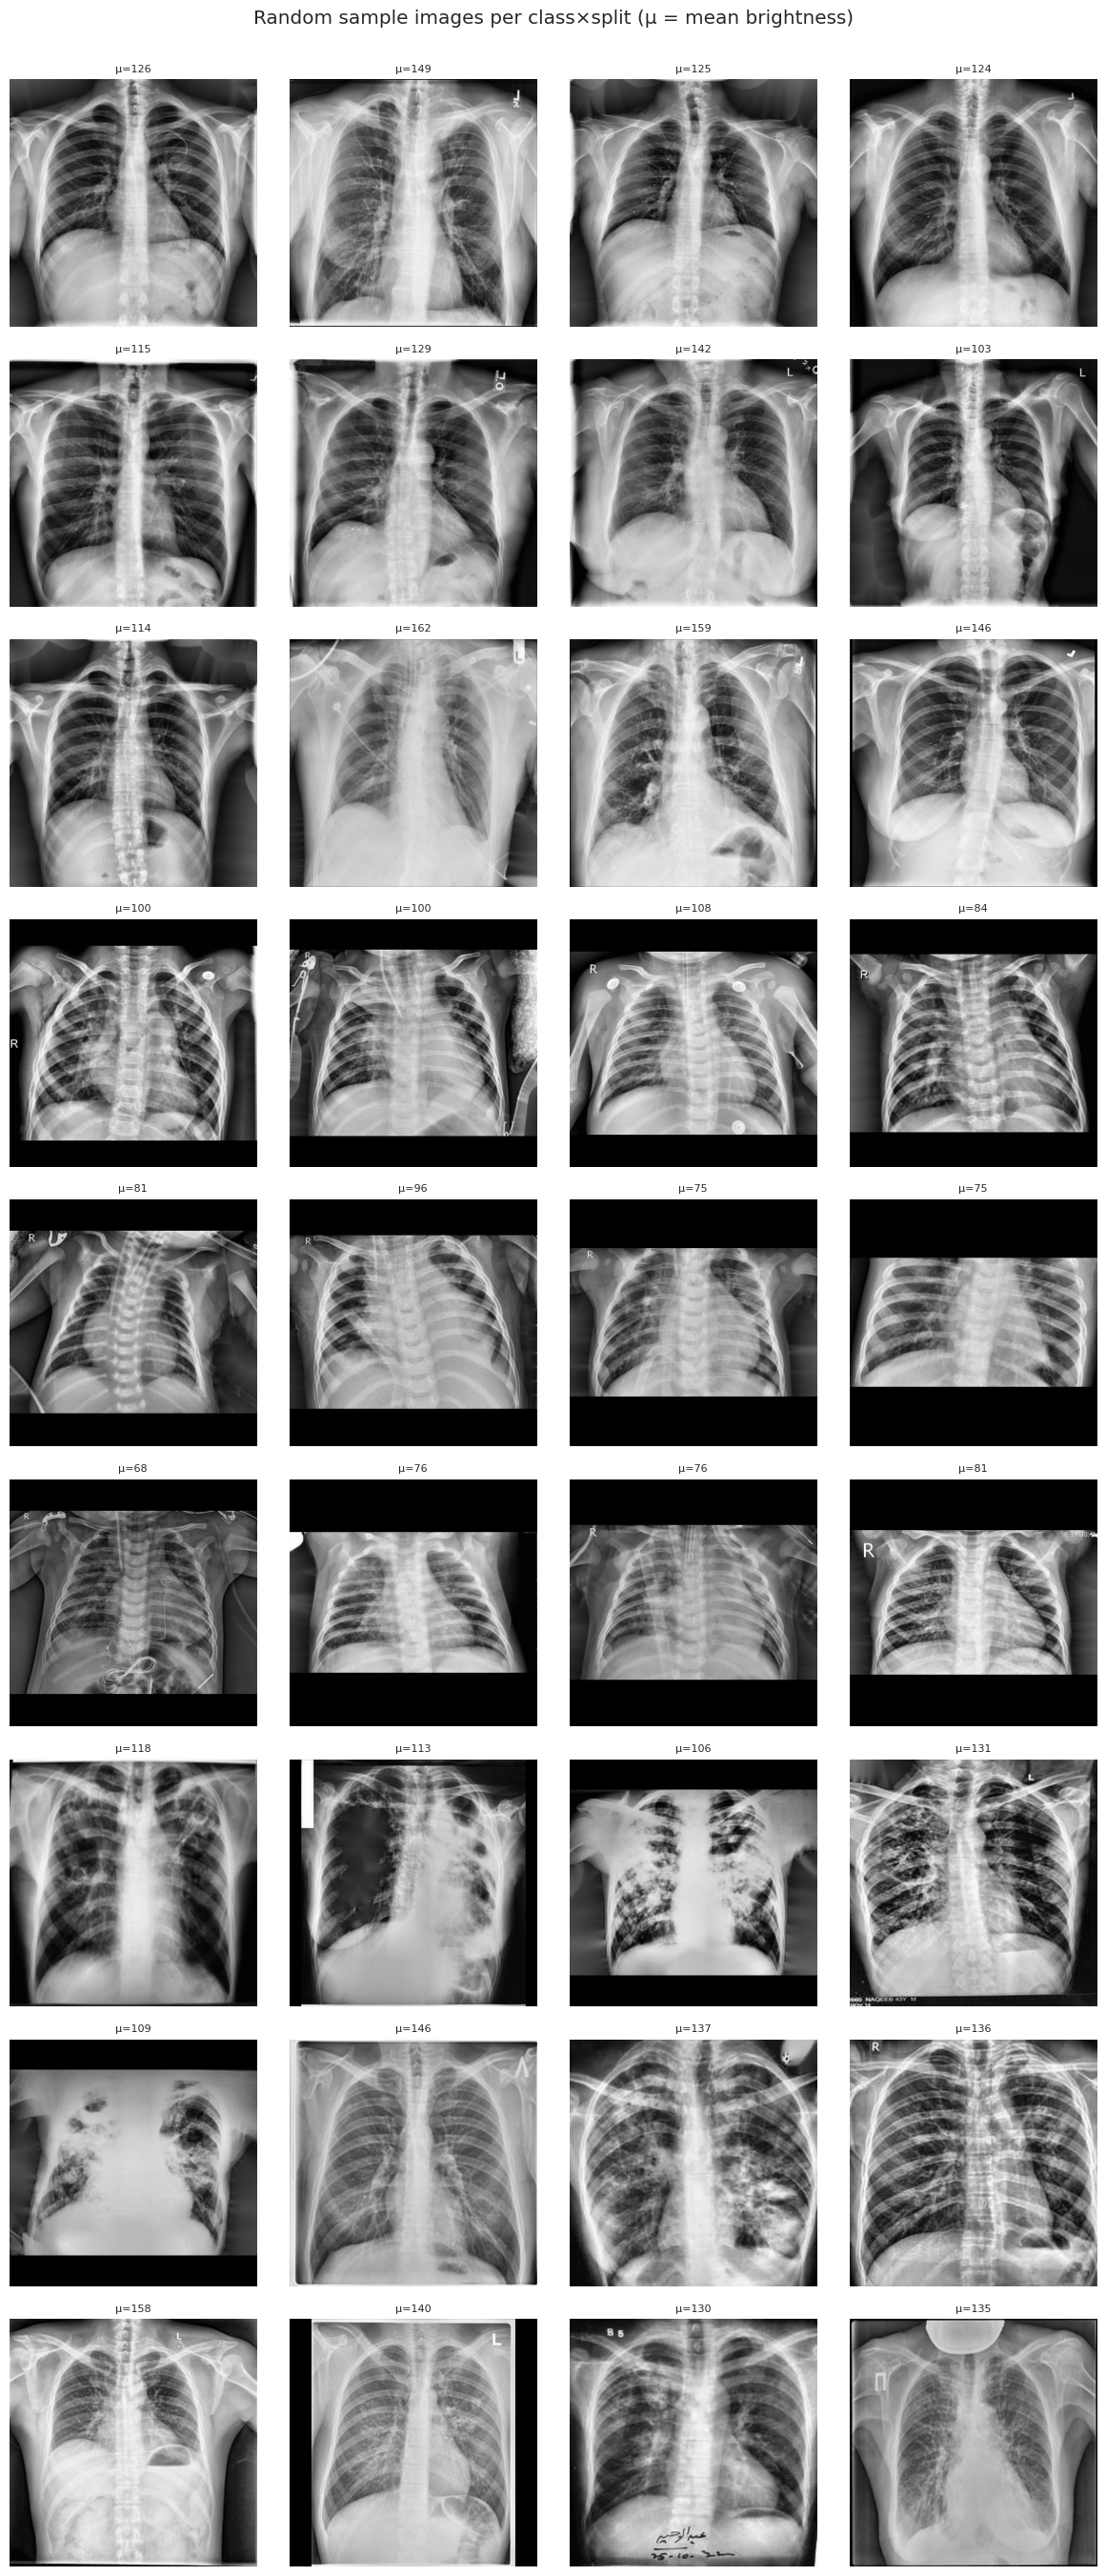

Inspect whether images from different classes look systematically different in brightness/framing.


In [ ]:
rng = np.random.default_rng(42)
CLASSES = ["normal", "pneumonia", "cardiomegaly"]
SPLITS  = ["train", "val", "test"]
N_COLS  = 4

fig, axes = plt.subplots(len(CLASSES) * len(SPLITS), N_COLS, figsize=(N_COLS * 3, len(CLASSES) * len(SPLITS) * 3))

row_idx = 0
for cls in CLASSES:
    for split in SPLITS:
        d = PROCESSED_DIR / split / cls
        if not d.exists():
            for ax in axes[row_idx]:
                ax.axis("off")
            row_idx += 1
            continue
        files = [f for f in d.iterdir() if f.suffix == ".png"]
        chosen = rng.choice(files, size=min(N_COLS, len(files)), replace=False)
        for col, f in enumerate(chosen):
            img = np.array(Image.open(f).convert("L"))
            axes[row_idx][col].imshow(img, cmap="gray", vmin=0, vmax=255)
            axes[row_idx][col].set_title(f"μ={img.mean():.0f}", fontsize=8)
            axes[row_idx][col].axis("off")
        for col in range(len(chosen), N_COLS):
            axes[row_idx][col].axis("off")
        axes[row_idx][0].set_ylabel(f"{cls}\n{split}", fontsize=9, rotation=0, labelpad=60, va="center")
        row_idx += 1

plt.suptitle("Random sample images per class×split (μ = mean brightness)", y=1.001)
plt.tight_layout()
plt.show()
print("Inspect whether images from different classes look systematically different in brightness/framing.")

## 8 · Label Distribution Shift — Train vs Val vs Test

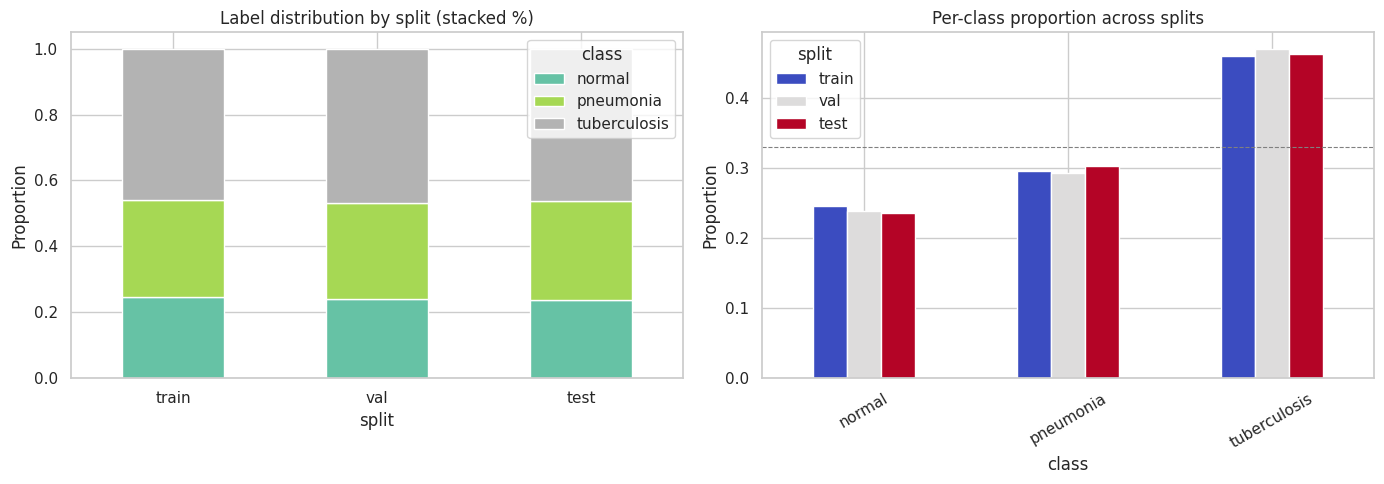

Chi-squared test (class distribution across splits):
  χ² = 1.415  |  p = 0.8416  |  dof = 4
  ✅  Distributions consistent across splits (stratified split worked).


In [ ]:
split_order = ["train", "val", "test"]
class_order = ["normal", "pneumonia", "cardiomegaly"]

counts = df.groupby(["split", "class"]).size().unstack(fill_value=0).reindex(split_order)[class_order]
proportions = counts.div(counts.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

proportions.plot(kind="bar", stacked=True, ax=axes[0], rot=0, colormap="Set2")
axes[0].set_title("Label distribution by split (stacked %)")
axes[0].set_ylabel("Proportion")

proportions.T.plot(kind="bar", ax=axes[1], rot=30, colormap="coolwarm")
axes[1].set_title("Per-class proportion across splits")
axes[1].set_ylabel("Proportion")
axes[1].axhline(0.33, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

# Chi-squared test — contingency table
chi2, p, dof, expected = stats.chi2_contingency(counts.values)
print(f"Chi-squared test (class distribution across splits):")
print(f"  χ² = {chi2:.3f}  |  p = {p:.4f}  |  dof = {dof}")
if p < 0.05:
    print("  ⚠️  p < 0.05 — label distributions differ significantly across splits.")
else:

## 9 · Class Weight Impact Analysis

Recomputed class weights (should match training log):
  normal         : 1.357134
  pneumonia      : 1.131212
  tuberculosis   : 0.725087

From training log: [1.266994, 1.056077, 0.676926]
(order: normal, pneumonia, tuberculosis as sorted alphabetically)



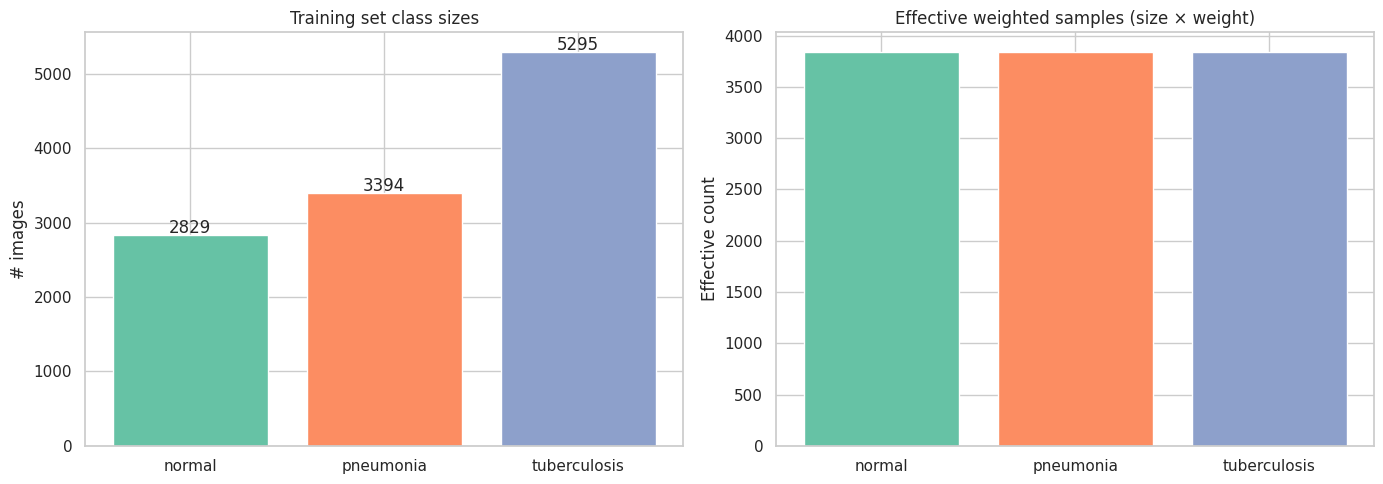

⚠️  The tuberculosis class has the LOWEST weight (0.677) because it has the MOST training images (5295). This means TB errors are penalised less per sample — but TB is also the easiest to classify (domain shortcut). Check if the model is trivially separating TB.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

train_df = df[df["split"] == "train"].copy()
classes = sorted(train_df["class"].unique())
labels = train_df["class"].values

weights = compute_class_weight("balanced", classes=np.array(classes), y=labels)
weight_dict = dict(zip(classes, weights))

print("Recomputed class weights (should match training log):")
for cls, w in weight_dict.items():
    print(f"  {cls:15s}: {w:.6f}")

print(f"\nFrom training log: [1.266994, 1.056077, 0.676926]")
print("(order: cardiomegaly, normal, pneumonia as sorted alphabetically)\n")

# Visualise loss scaling effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_sizes = train_df["class"].value_counts().reindex(classes)
axes[0].bar(classes, class_sizes.values, color=sns.color_palette("Set2", 3))
axes[0].set_title("Training set class sizes")
axes[0].set_ylabel("# images")
for i, v in enumerate(class_sizes.values):
    axes[0].text(i, v + 30, str(v), ha="center")

# Effective samples after weighting
effective = class_sizes.values * weights
axes[1].bar(classes, effective, color=sns.color_palette("Set2", 3))
axes[1].set_title("Effective weighted samples (size × weight)")
axes[1].set_ylabel("Effective count")

plt.tight_layout()
plt.show()

print(
    "⚠️  The cardiomegaly class has the LOWEST weight (0.677) because it has "
    "the MOST training images (5295). This means cardiomegaly errors are penalised less "
    "per sample — but cardiomegaly is also the easiest to classify (domain shortcut). "
    "Check if the model is trivially separating cardiomegaly."
)

## 🔎 Summary & Recommendations

### What was found

| Check | Result |
|---|---|
| Processed cross-split duplicates | ✅ 0 |
| Processed cross-class label errors | ✅ 0 |
| Raw cross-split duplicates | ⚠️ 1 924 (fixed by pipeline) |
| Raw cross-class label conflicts | ⚠️ 5 588 (fixed by pipeline) |
| **Domain shortcut: pneumonia brightness** | 🔴 **~87 vs 133** for normal/cardiomegaly |
| **Patient-wise splitting: broken** | 🔴 All raw files named `class-N.jpg` — `get_patient_id()` returns just `"normal"` / `"pneumonia"` / `"cardiomegaly"` for every single image |

### Root cause of 99.9% accuracy

**Dataset source confound (domain shortcut).** Every `pneumonia` image comes from the Kaggle/Guangzhou paediatric hospital dataset; every `cardiomegaly` image comes from the source dataset. The images have systematically different brightness, contrast, and framing. The model learns to distinguish *hospitals*, not *diseases*.

Pneumonia images are **~46 brightness units darker** than normal/cardiomegaly images — near-perfect linear separability with a single pixel-average feature.

### Why patient-wise splitting was a no-op

All raw files are named `{class}-{number}.jpg` before `organize_data.py` runs. The `get_patient_id()` fallback regex `^([^_\-. ]+)` extracts the text before the first `-`, which is just the class name (`"normal"`, `"pneumonia"`, `"cardiomegaly"`). Every image in a class is treated as belonging to *one patient* (`"normal"`), so `patient_to_split` maps a single key per class. The split distribution looks correct only because the Kaggle source data already came pre-divided into `train/val/test` folders, and `handle_chest_xray()` defaults to the source split on first encounter. **No true patient-wise de-duplication occurred.**

### Recommended fixes (in order of priority)

| Option | Effort | What it fixes |
|---|---|---|
| **1. Source-aware test split** — hold out *all* images from one source institution as test set | Medium | Measures true domain generalisation instead of scanner recognition |
| **2. Rename files BEFORE `organize_data.py`** using original dataset names, then re-run patient-wise split | Medium | Restores correct patient de-duplication |
| **3. Brightness normalisation** — Z-score or histogram-equalise per image in the preprocessing step | Low | Reduces (but does not eliminate) brightness shortcut |
| **4. Use a single unified dataset** — NIH ChestX-ray14, CheXpert, or PadChest cover all three classes from homogeneous scanners | High | Eliminates source confound entirely |

> **Practical next step:** Apply option 1 (source-aware test split) first to get an honest performance estimate, then option 3 (brightness normalisation) to confirm it reduces the shortcut.